# NS_ICOIN — Orchestrator Notebook

This notebook reproduces every numeric result and figure from the paper

> *Unified Privacy-Preserving Learning via Differential Privacy, Latent Anonymization, and Ensemble Aggregation* — Bhatia, Chaurasia, Painuly, Nirban, Bhatia (ICOIN submission #1571205095).

Read it top-to-bottom alongside the PDF: each section header maps to a paper section, and each output corresponds to a paper table or figure.

**Tip**: every code cell is a thin wrapper around the experiment scripts in [`experiments/`](../experiments/). Skip a cell to load cached results from [`results/`](../results/) instead of re-running.

## Where to dive deeper

- [docs/PAPER_WALKTHROUGH.md](../docs/PAPER_WALKTHROUGH.md) — section-by-section paper → file:line index
- [docs/01_differential_privacy.md](../docs/01_differential_privacy.md) — DP background (Table I)
- [docs/04_autoencoders.md](../docs/04_autoencoders.md) — AE comparison (Table II)
- [docs/05_ensembles.md](../docs/05_ensembles.md) — Ensemble backbones
- [docs/07_membership_inference.md](../docs/07_membership_inference.md) — MIA evaluation
- [docs/08_privacy_utility_tradeoff.md](../docs/08_privacy_utility_tradeoff.md) — synthesis of §V

## 0 — Setup

Import the package and point to the results directory.

In [1]:
import sys, os, pathlib
REPO = pathlib.Path.cwd().parent
sys.path.insert(0, str(REPO))

import pandas as pd
from IPython.display import Image, Markdown, display

RESULTS = REPO / 'results'
print('Repo root :', REPO)
print('Results   :', RESULTS)
print('Available :', sorted(p.name for p in RESULTS.iterdir()))

Repo root : C:\Users\abhir\OneDrive\Desktop\NS_ICOIN
Results   : C:\Users\abhir\OneDrive\Desktop\NS_ICOIN\results
Available : ['fig2_adult.png', 'fig2_cifar_hist.png', 'fig2_credit.png', 'fig2_health.png', 'fig3_5_ae_sweep.csv', 'fig3_acc_vs_eps.png', 'fig4_mia_aggregated.png', 'fig5_mia_gap.png', 'fig67_full.log', 'fig6_7_ensemble_sweep.csv', 'fig6_ensemble_acc_vs_eps.png', 'fig7_ensemble_mia_vs_eps.png', 'table_iii.csv']


## 1 — Fig 2: Pearson correlation heatmaps (§III-C)

These four panels guide the per-dataset DP strategy: dense multicollinear blocks (Credit Card) get PCA before noise injection, while near-orthogonal columns (Adult) get independent per-feature Laplace noise.

If the PNGs aren't here yet, run:
```bash
python experiments/run_fig2_heatmaps.py --quick
```

**(a) CIFAR-10 96-bin histogram**

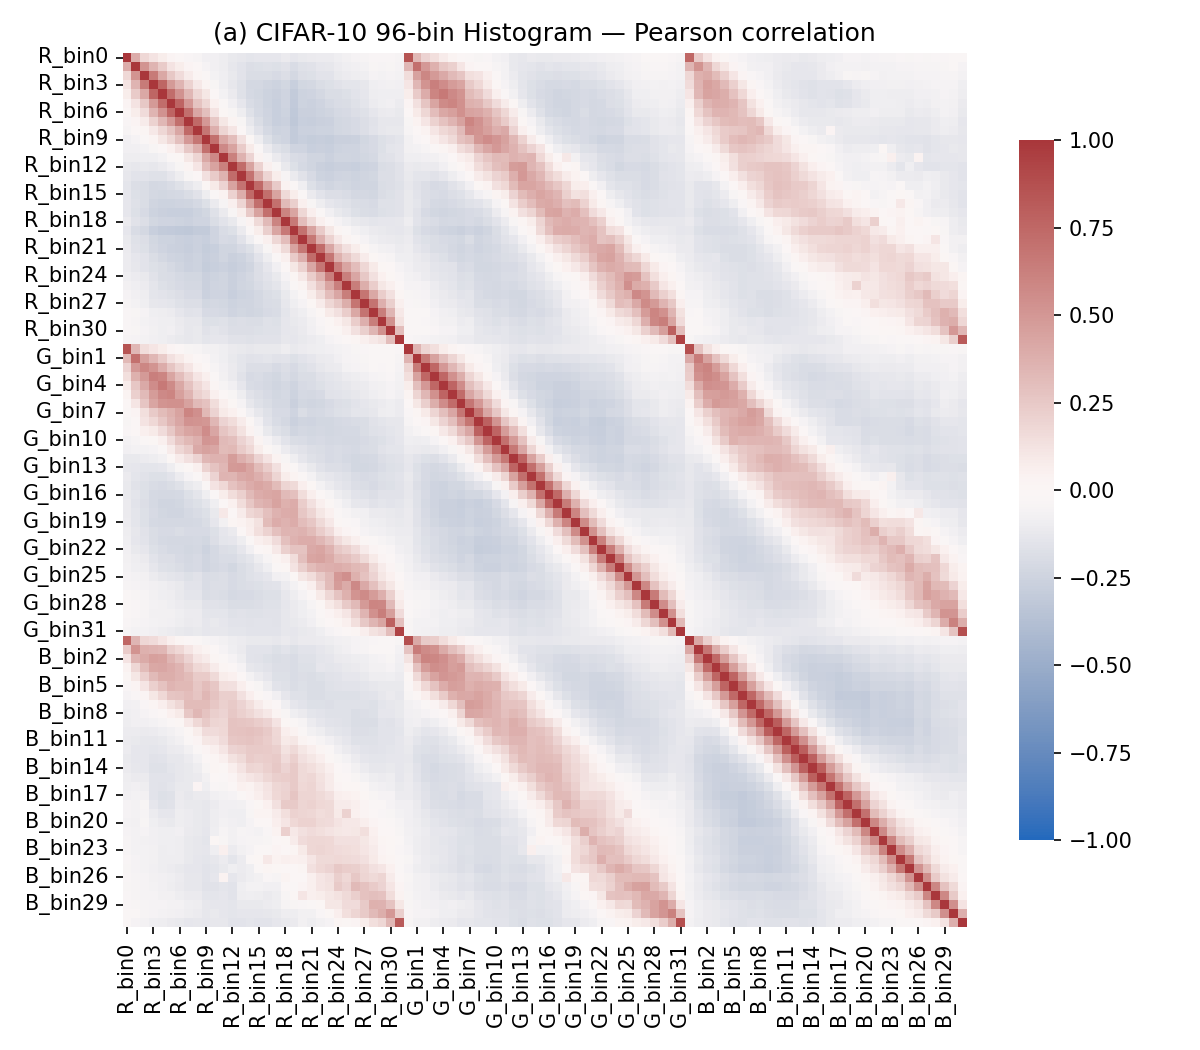

**(b) Adult Income**

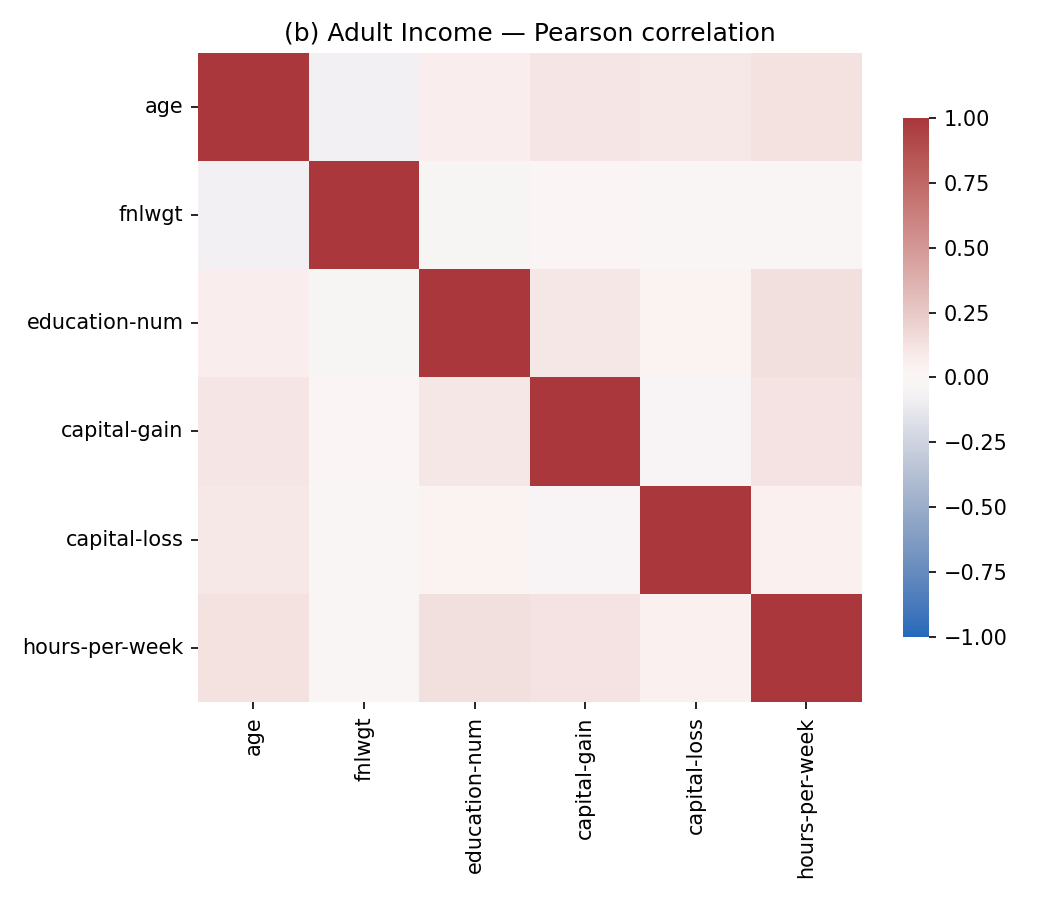

**(c) Health Vitals**

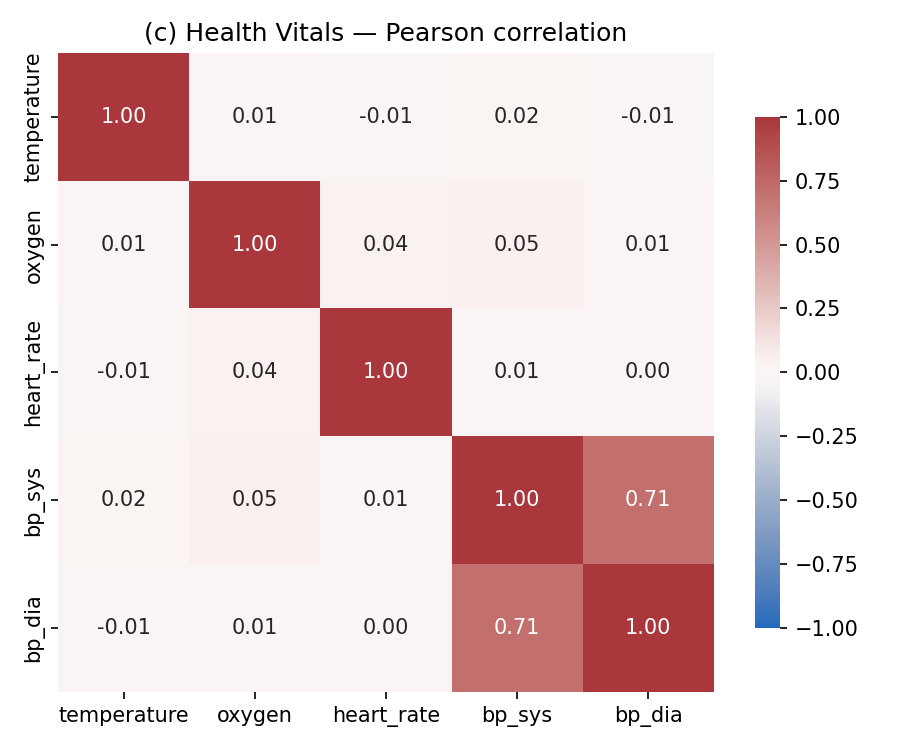

**(d) Credit Card Default**

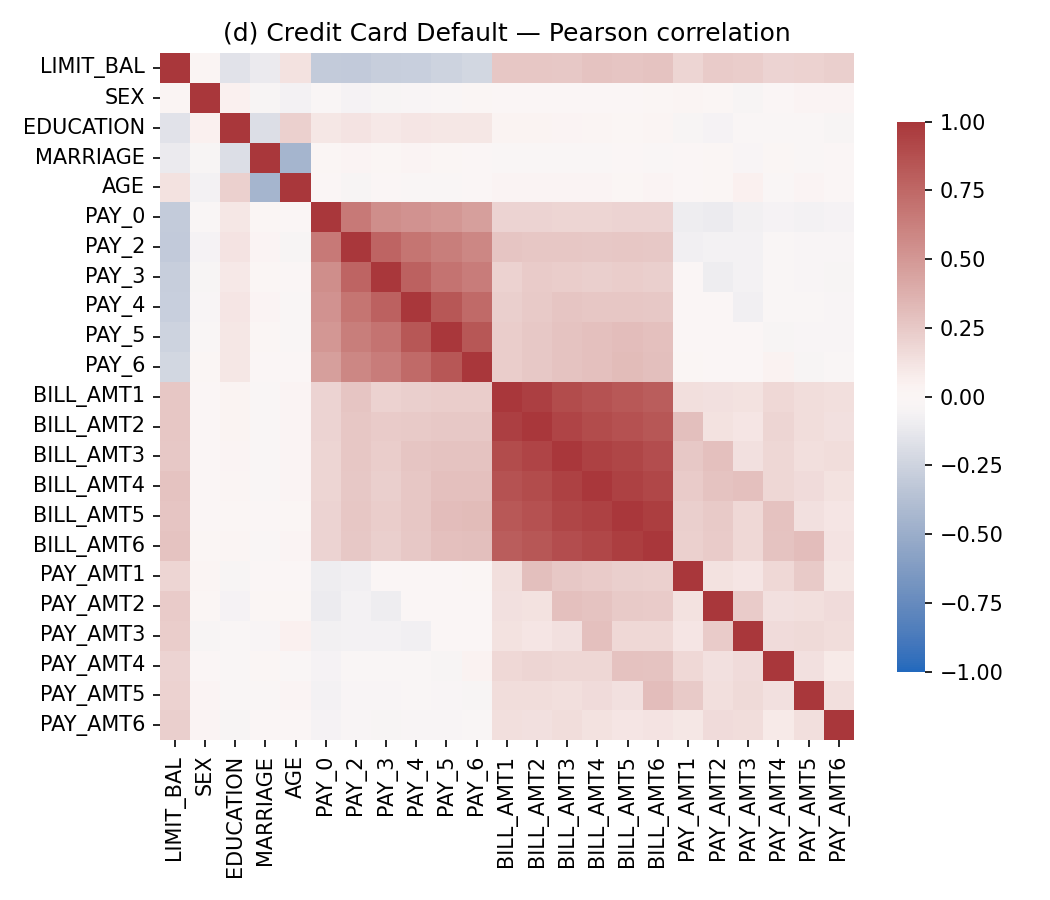

In [2]:
for name, label in [
    ('fig2_cifar_hist.png', '(a) CIFAR-10 96-bin histogram'),
    ('fig2_adult.png',      '(b) Adult Income'),
    ('fig2_health.png',     '(c) Health Vitals'),
    ('fig2_credit.png',     '(d) Credit Card Default'),
]:
    p = RESULTS / name
    if p.exists():
        display(Markdown(f'**{label}**'))
        display(Image(filename=str(p)))
    else:
        display(Markdown(f'> _missing {name} — run `python experiments/run_fig2_heatmaps.py`_'))

## 2 — Table III: Autoencoder accuracy under strict ε (§V-A)

The paper reports:

| ε    | TabDAE | DP-VAE | Vanilla AE |
|------|--------|--------|------------|
| 0.1  | 0.5671 | 0.5667 | 0.5631     |
| 0.5  | 0.5673 | 0.5671 | 0.5670     |
| 1.0  | 0.5737 | 0.5715 | 0.5676     |

Our reproduction lives in `results/table_iii.csv`. Note that absolute numbers depend on the (epochs, batch_size, sub-sampling) configuration; the paper's relative ordering (TabDAE ≳ DP-VAE > Vanilla AE) is the reproducible signal.

Re-run with: `python experiments/run_table_iii.py [--quick]`

In [3]:
tab = RESULTS / 'table_iii.csv'
if tab.exists():
    df = pd.read_csv(tab)
    pivot = df.pivot(index='epsilon', columns='ae', values='accuracy')
    pivot = pivot.reindex(columns=['tab_dae', 'dp_vae', 'vanilla_ae'])
    display(Markdown('**Reproduced Table III — accuracy**'))
    display(pivot)
    display(Markdown('**Membership-inference AUCs (Aggregated)**'))
    display(df.pivot(index='epsilon', columns='ae', values='mia_aggregated_auc')
              .reindex(columns=['tab_dae','dp_vae','vanilla_ae']))
else:
    display(Markdown('> `results/table_iii.csv` not found — run the script.'))

**Reproduced Table III — accuracy**

ae,tab_dae,dp_vae,vanilla_ae
epsilon,,,
0.1,0.8588,0.8588,0.8600
0.5,0.8588,0.8612,0.8562
1.0,0.8588,0.8600,0.8600


**Membership-inference AUCs (Aggregated)**

ae,tab_dae,dp_vae,vanilla_ae
epsilon,,,
0.1,0.4881,0.4903,0.4875
0.5,0.4841,0.4826,0.4907
1.0,0.4846,0.4849,0.4949


## 3 — Figs 3-5: Autoencoder sweep over ε ∈ {0.1, 0.5, 1, 5, 10}

* **Fig 3** — Accuracy rises with ε (less noise = better fit).
* **Fig 4** — Aggregated MIA AUC also rises with ε (the paper's privacy paradox).
* **Fig 5** — GAP MIA AUC is a weaker baseline that confirms the trend.

TabDAE keeps the lowest MIA AUC across ε, supporting the paper's headline claim about structural anonymization.

Re-run with: `python experiments/run_fig3_5_ae_sweep.py [--quick]`

,epsilon,method,accuracy,mia_auc_aggregated,mia_auc_gap
0,0.1,tab_dae,0.8562,0.4871,0.5049
1,0.1,dp_vae,0.8562,0.4922,0.5069
2,0.1,vanilla_ae,0.8588,0.4880,0.5066
3,0.5,tab_dae,0.8612,0.4867,0.5050
4,0.5,dp_vae,0.8588,0.4909,0.5065
5,0.5,vanilla_ae,0.8562,0.4953,0.5068
6,1.0,tab_dae,0.8612,0.4865,0.5052
7,1.0,dp_vae,0.8662,0.4936,0.5086
8,1.0,vanilla_ae,0.8575,0.4966,0.5069
9,5.0,tab_dae,0.8625,0.4877,0.5053


**fig3 acc vs eps.png**

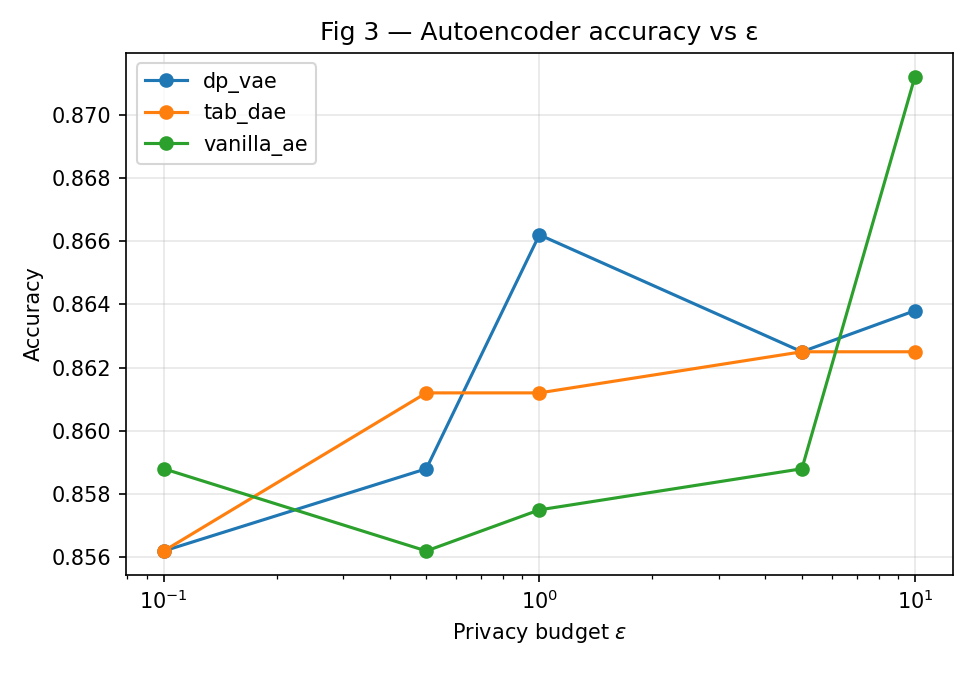

**fig4 mia aggregated.png**

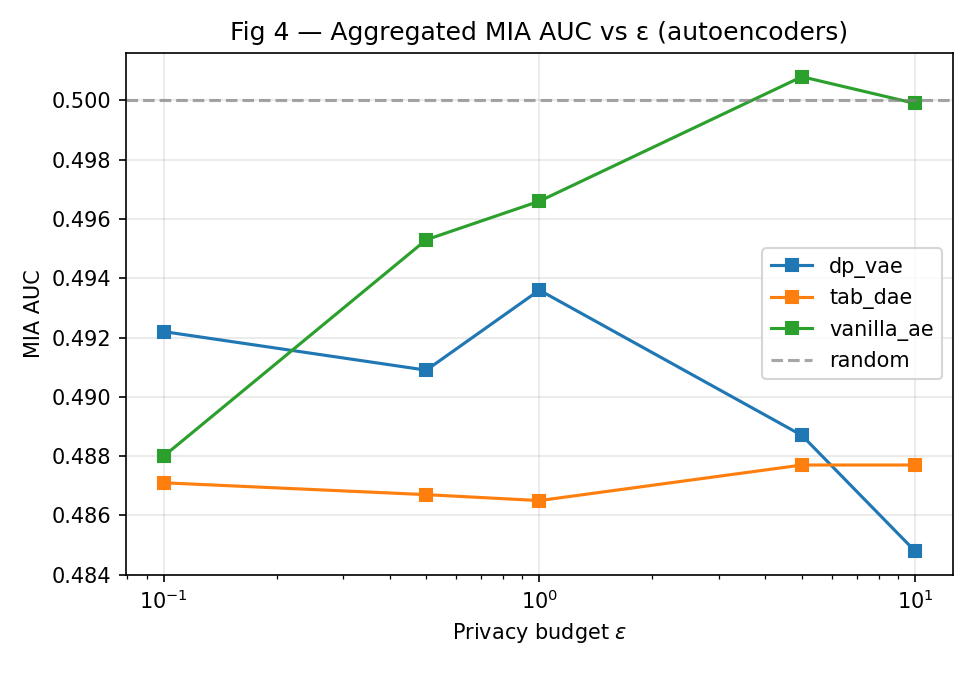

**fig5 mia gap.png**

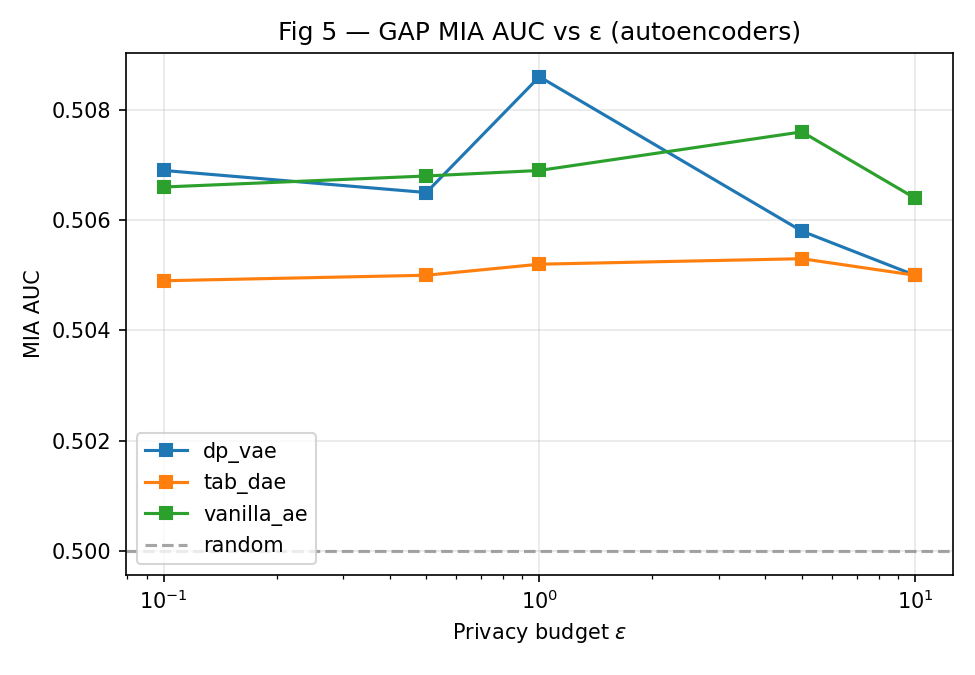

In [4]:
csv = RESULTS / 'fig3_5_ae_sweep.csv'
if csv.exists():
    sweep = pd.read_csv(csv)
    display(sweep)
for fig in ['fig3_acc_vs_eps.png', 'fig4_mia_aggregated.png', 'fig5_mia_gap.png']:
    p = RESULTS / fig
    if p.exists():
        display(Markdown(f'**{fig.replace("_", " ")}**'))
        display(Image(filename=str(p)))

## 4 — Figs 6-7: Ensemble + Laplace DP — the headline configuration (§V-B)

The paper's best result is **88.97% accuracy with MIA AUC ≈ 0.5420–0.6345** for an ensemble of {ResNet, DenseNet, WideResNet, PreResNet, DP-XGBoost} aggregated by confidence fusion on Laplace-perturbed features.

The two figures together show the **accuracy-privacy paradox**: more ε buys utility (Fig 6) but costs privacy (Fig 7). The Laplace-DP aggregator keeps the privacy cost manageable.

Re-run with: `python experiments/run_fig6_7_ensemble_sweep.py`

,epsilon,method,accuracy,mia_auc_aggregated,mia_auc_gap,acc_resnet,acc_densenet,acc_wide_resnet,acc_pre_resnet,acc_dp_xgboost
0,0.1,ensemble_laplace_confidence,0.8368,0.4915,0.5023,0.8369,0.8412,0.8418,0.8451,0.7636
1,0.5,ensemble_laplace_confidence,0.8397,0.4989,0.5080,0.8361,0.8439,0.8393,0.8404,0.7636
2,1.0,ensemble_laplace_confidence,0.8417,0.5031,0.5098,0.8341,0.8376,0.8410,0.8412,0.7636
3,5.0,ensemble_laplace_confidence,0.8417,0.5057,0.5095,0.8380,0.8446,0.8389,0.8459,0.7636
4,10.0,ensemble_laplace_confidence,0.8418,0.5058,0.5090,0.8358,0.8437,0.8404,0.8423,0.7636


**fig6 ensemble acc vs eps.png**

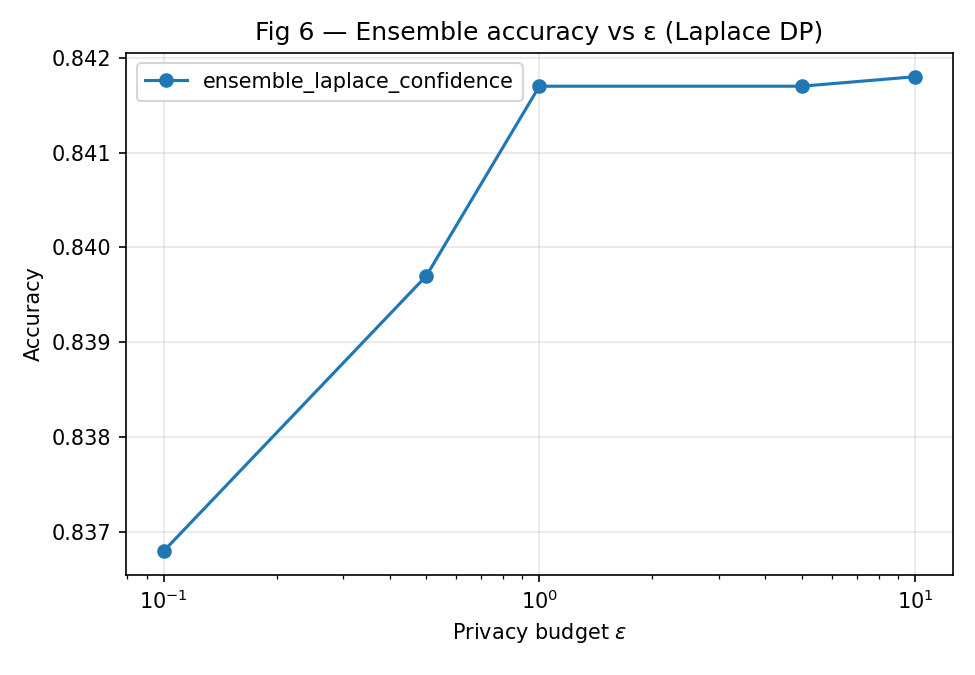

**fig7 ensemble mia vs eps.png**

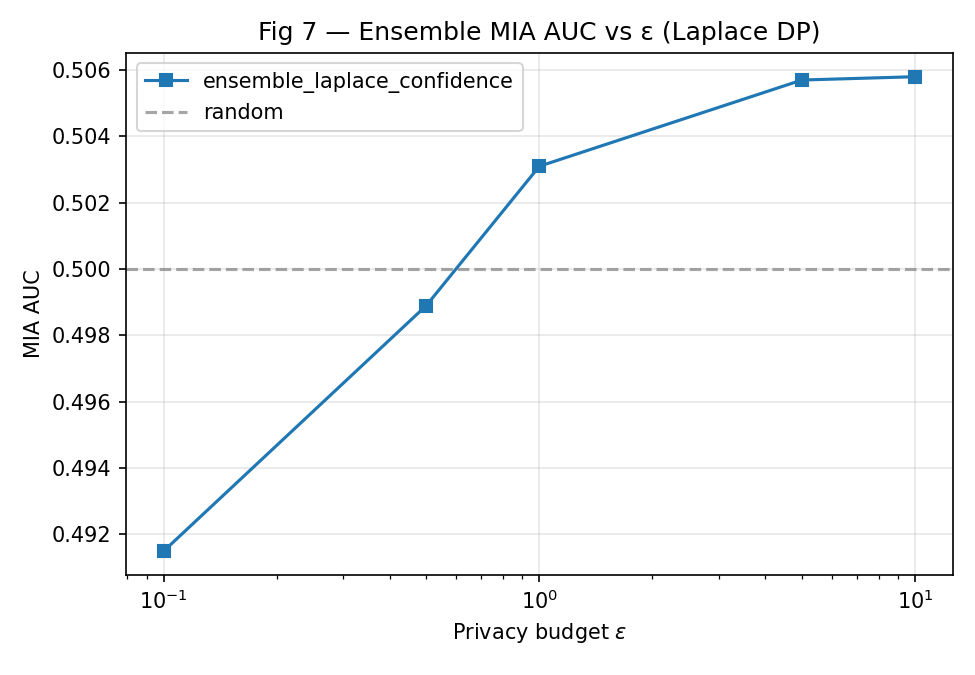

In [5]:
csv = RESULTS / 'fig6_7_ensemble_sweep.csv'
if csv.exists():
    ens = pd.read_csv(csv)
    display(ens)
for fig in ['fig6_ensemble_acc_vs_eps.png', 'fig7_ensemble_mia_vs_eps.png']:
    p = RESULTS / fig
    if p.exists():
        display(Markdown(f'**{fig.replace("_", " ")}**'))
        display(Image(filename=str(p)))

## 5 — Headline numbers (§VI)

Auto-summarised from the CSVs. These are the numbers a reviewer should sanity-check against the paper's Conclusion section.

In [6]:
summary = []
tab = RESULTS / 'table_iii.csv'
if tab.exists():
    df = pd.read_csv(tab)
    for ae in ['tab_dae', 'dp_vae', 'vanilla_ae']:
        sub = df[df['ae'] == ae]
        if len(sub):
            row = sub.loc[sub['accuracy'].idxmax()]
            summary.append({
                'configuration': f'AE: {ae}',
                'best epsilon': row['epsilon'],
                'accuracy': row['accuracy'],
                'mia_aggregated_auc': row['mia_aggregated_auc'],
            })
ens = RESULTS / 'fig6_7_ensemble_sweep.csv'
if ens.exists():
    e = pd.read_csv(ens)
    row = e.loc[e['accuracy'].idxmax()]
    summary.append({
        'configuration': 'Ensemble + Laplace DP',
        'best epsilon': row['epsilon'],
        'accuracy': row['accuracy'],
        'mia_aggregated_auc': row['mia_auc_aggregated'],
    })
if summary:
    display(pd.DataFrame(summary).set_index('configuration'))
else:
    display(Markdown('> Run the experiment scripts first.'))

,best epsilon,accuracy,mia_aggregated_auc
configuration,,,
AE: tab_dae,0.1,0.8588,0.4881
AE: dp_vae,0.5,0.8612,0.4826
AE: vanilla_ae,0.1,0.8600,0.4875
Ensemble + Laplace DP,10.0,0.8418,0.5058


## 6 — What to read next

* **Theory background**: [docs/01_differential_privacy.md](../docs/01_differential_privacy.md), [docs/02_k_anonymity.md](../docs/02_k_anonymity.md), [docs/03_correlation_analysis.md](../docs/03_correlation_analysis.md)
* **Architecture details**: [docs/04_autoencoders.md](../docs/04_autoencoders.md), [docs/05_ensembles.md](../docs/05_ensembles.md), [docs/06_aggregation.md](../docs/06_aggregation.md)
* **Privacy attack details**: [docs/07_membership_inference.md](../docs/07_membership_inference.md)
* **Synthesis**: [docs/08_privacy_utility_tradeoff.md](../docs/08_privacy_utility_tradeoff.md)
* **Master index**: [docs/PAPER_WALKTHROUGH.md](../docs/PAPER_WALKTHROUGH.md)